# ⭐ Day 55: XGBoost
## The King of Gradient Boosting | Complete Tutorial with Examples & Exercises

**Day 55 of 369-day Python & AI Learning Path** 🚀

---

Welcome to Day 55! Today we dive deep into **XGBoost** (eXtreme Gradient Boosting) — the algorithm that has dominated Kaggle competitions and become the gold standard for structured data machine learning.

## 📋 Table of Contents

1. [Introduction to Gradient Boosting and Why XGBoost Wins](#1-introduction-to-gradient-boosting-and-why-xgboost-wins)
2. [How Gradient Boosting Works](#2-how-gradient-boosting-works)
3. [Key Innovations in XGBoost](#3-key-innovations-in-xgboost)
4. [Installing and Using XGBoost](#4-installing-and-using-xgboost)
5. [XGBoost Classifier vs Regressor](#5-xgboost-classifier-vs-regressor)
6. [Hyperparameters Deep Dive](#6-hyperparameters-deep-dive)
7. [Applying XGBoost to Titanic Dataset](#7-applying-xgboost-to-titanic-dataset)
8. [Feature Importance from XGBoost](#8-feature-importance-from-xgboost)
9. [Early Stopping and Cross-Validation](#9-early-stopping-and-cross-validation)
10. [Comparison: Random Forest vs XGBoost](#10-comparison-random-forest-vs-xgboost)
11. [Practical Tips for Using XGBoost](#11-practical-tips-for-using-xgboost)
12. [Hands-On Exercises](#-hands-on-exercises)
13. [Solutions](#solutions-review-after-attempting)


## 1. Introduction to Gradient Boosting and Why XGBoost Wins

Gradient Boosting is an ensemble technique that builds models sequentially, where each new model attempts to correct the errors made by previous models. Unlike Random Forest, which builds trees independently and averages their predictions, Gradient Boosting creates a **strong learner** from many **weak learners** through additive training.

### Why XGBoost Dominates:

⚡ **Speed**: Optimized C++ backend with parallel processing

🎯 **Accuracy**: Regularization prevents overfitting better than standard GBM

🔧 **Flexibility**: Handles missing values automatically, supports custom objectives

📊 **Scalability**: Distributed computing support for massive datasets

🏆 **Proven Track Record**: Winner of numerous Kaggle competitions

XGBoost improves upon traditional Gradient Boosting through:
- **Regularization** (L1 & L2) to control model complexity
- **Second-order Taylor expansion** for faster convergence
- **Smart tree pruning** using max_depth and gamma
- **Built-in cross-validation** and early stopping
- **Weighted Quantile Sketch** for efficient split finding

## 2. How Gradient Boosting Works

### Sequential Error Correction Process:

1. **Initialize** with a base prediction (usually the mean for regression, log-odds for classification)

2. **Calculate residuals** (pseudo-residuals) = negative gradient of loss function

3. **Fit a weak learner** (decision tree) to these residuals

4. **Update predictions**: New Prediction = Old Prediction + (learning_rate × Tree Prediction)

5. **Repeat** steps 2-4 for n_estimators iterations

### Mathematical Intuition:

```
F_m(x) = F_{m-1}(x) + ν · h_m(x)
```

Where:
- F_m(x) = Ensemble model at iteration m
- ν (nu) = learning_rate (shrinkage factor)
- h_m(x) = Weak learner fitted to residuals

The key insight: Each tree learns from the **mistakes** of the ensemble so far, gradually reducing the overall error.

## 3. Key Innovations in XGBoost

### 🛡️ Regularization (L1 + L2)

XGBoost adds regularization terms to the objective function:

```
Objective = Σ Loss(y_i, ŷ_i) + Σ Ω(f_k)
```

Where Ω(f) = γT + ½λΣw² + αΣ|w| (T = number of leaves, w = leaf weights)

- **reg_lambda (λ)**: L2 regularization on leaf weights (default: 1)
- **reg_alpha (α)**: L1 regularization for sparsity (default: 0)

### ✂️ Tree Pruning

Unlike GBM's greedy approach, XGBoost uses **max_depth** parameter and prunes trees backward. A split is only made if:

```
Gain = ½[(G_L²/(H_L+λ)) + (G_R²/(H_R+λ)) - ((G_L+G_R)²/(H_L+H_R+λ))] - γ
```

If Gain < γ, the split is removed. This is controlled by the **gamma** parameter.

### 🔄 Handling Missing Values

XGBoost learns the **best direction** for missing values during training. For each split, it tries both left and right directions and chooses the one that minimizes loss.

### 📈 Weighted Quantile Sketch

For large datasets, XGBoost uses approximate split finding by proposing candidate split points based on percentiles of feature distributions, making it scalable to millions of rows.

### ⚡ Parallel & Distributed Computing

- **Feature Parallelism**: Different threads scan different features to find best splits
- **Data Parallelism**: Data distributed across machines (for massive datasets)
- **Cache-aware Access**: Optimized memory access patterns for tree construction

## 4. Installing and Using XGBoost

Let's install XGBoost and verify the installation.

In [1]:
# Install XGBoost (uncomment if needed)
# !pip install xgboost

# Import necessary libraries
import xgboost as xgb
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_breast_cancer, fetch_california_housing
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestClassifier
import warnings
warnings.filterwarnings('ignore')

# Set style for visualizations
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

print(f"✅ XGBoost version: {xgb.__version__}")
print(f"✅ NumPy version: {np.__version__}")
print(f"✅ Pandas version: {pd.__version__}")

✅ XGBoost version: 3.2.0
✅ NumPy version: 2.0.2
✅ Pandas version: 2.3.3


## 5. XGBoost Classifier vs Regressor

XGBoost provides two main APIs:
- **Scikit-learn API**: `XGBClassifier` and `XGBRegressor` (easier integration)
- **Native API**: `DMatrix` with `train()` (more control, faster)

Let's explore both classification and regression examples.

In [2]:
# ⚡ Example 1: XGBoost Classifier
print("=" * 60)
print("🌲 XGBOOST CLASSIFIER EXAMPLE")
print("=" * 60)

# Load breast cancer dataset
cancer = load_breast_cancer()
X_cancer = pd.DataFrame(cancer.data, columns=cancer.feature_names)
y_cancer = cancer.target

print(f"Dataset shape: {X_cancer.shape}")
print(f"Target distribution: {np.bincount(y_cancer)}")

# Split data
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_cancer, y_cancer, test_size=0.2, random_state=42, stratify=y_cancer
)

# Initialize and train XGBoost Classifier
xgb_clf = xgb.XGBClassifier(
    n_estimators=100,
    max_depth=3,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

xgb_clf.fit(X_train_c, y_train_c)

# Predictions
y_pred_c = xgb_clf.predict(X_test_c)
accuracy = accuracy_score(y_test_c, y_pred_c)

print(f"\n✅ Test Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test_c, y_pred_c, target_names=['Malignant', 'Benign']))

🌲 XGBOOST CLASSIFIER EXAMPLE
Dataset shape: (569, 30)
Target distribution: [212 357]

✅ Test Accuracy: 0.9474

Classification Report:
              precision    recall  f1-score   support

   Malignant       0.95      0.90      0.93        42
      Benign       0.95      0.97      0.96        72

    accuracy                           0.95       114
   macro avg       0.95      0.94      0.94       114
weighted avg       0.95      0.95      0.95       114



📈 XGBOOST REGRESSOR EXAMPLE
Dataset shape: (20640, 8)

✅ RMSE: 0.4936
✅ R² Score: 0.8141


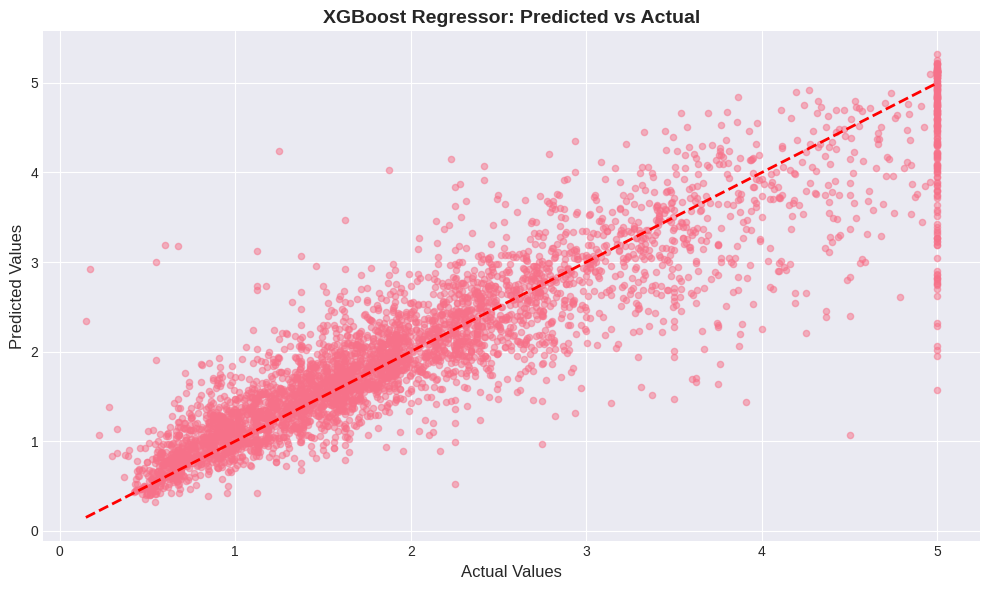

In [3]:
# ⚡ Example 2: XGBoost Regressor
print("=" * 60)
print("📈 XGBOOST REGRESSOR EXAMPLE")
print("=" * 60)

# Load California housing dataset
housing = fetch_california_housing()
X_housing = pd.DataFrame(housing.data, columns=housing.feature_names)
y_housing = housing.target

print(f"Dataset shape: {X_housing.shape}")

# Split data
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(
    X_housing, y_housing, test_size=0.2, random_state=42
)

# Initialize and train XGBoost Regressor
xgb_reg = xgb.XGBRegressor(
    n_estimators=100,
    max_depth=5,
    learning_rate=0.1,
    random_state=42
)

xgb_reg.fit(X_train_r, y_train_r)

# Predictions
y_pred_r = xgb_reg.predict(X_test_r)
mse = mean_squared_error(y_test_r, y_pred_r)
rmse = np.sqrt(mse)
r2 = r2_score(y_test_r, y_pred_r)

print(f"\n✅ RMSE: {rmse:.4f}")
print(f"✅ R² Score: {r2:.4f}")

# Visualize predictions vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test_r, y_pred_r, alpha=0.5, s=20)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.xlabel('Actual Values', fontsize=12)
plt.ylabel('Predicted Values', fontsize=12)
plt.title('XGBoost Regressor: Predicted vs Actual', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

## 6. Hyperparameters Deep Dive

Understanding XGBoost hyperparameters is crucial for optimal performance. Here's a comprehensive guide:

### 🎯 Core Parameters:

| Parameter | Description | Default | Typical Range |
|-----------|-------------|---------|---------------|
| `n_estimators` | Number of boosting rounds | 100 | 100-1000 |
| `learning_rate` | Shrinkage factor (η) | 0.3 | 0.01-0.3 |
| `max_depth` | Maximum tree depth | 6 | 3-10 |
| `subsample` | Fraction of samples per tree | 1.0 | 0.6-1.0 |
| `colsample_bytree` | Fraction of features per tree | 1.0 | 0.6-1.0 |

### 🛡️ Regularization Parameters:

| Parameter | Description | Default | Purpose |
|-----------|-------------|---------|---------|
| `reg_alpha` | L1 regularization | 0 | Feature selection |
| `reg_lambda` | L2 regularization | 1 | Weight shrinkage |
| `gamma` | Min loss reduction for split | 0 | Tree pruning |
| `min_child_weight` | Min sum of instance weight | 1 | Prevent overfitting |

### 📊 Learning Task Parameters:

| Parameter | Options | Use Case |
|-----------|---------|----------|
| `objective` | binary:logistic, multi:softmax, reg:squarederror | Task type |
| `eval_metric` | rmse, mae, logloss, error, auc | Evaluation |
| `scale_pos_weight` | numeric | Imbalanced data |

### 💡 Tuning Strategy:

1. **Start with defaults** and establish baseline
2. **Tune `max_depth`** and `min_child_weight` together
3. **Adjust `subsample`** and `colsample_bytree`** for regularization
4. **Fine-tune `learning_rate`** and `n_estimators`** (inverse relationship)
5. **Apply regularization** (`reg_alpha`, `reg_lambda`, `gamma`) if overfitting

In [4]:
# ⚡ Hyperparameter Tuning Example
print("=" * 60)
print("🔧 HYPERPARAMETER TUNING DEMONSTRATION")
print("=" * 60)

# Define parameter grid for tuning
param_grid = {
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1, 0.3],
    'n_estimators': [100, 200],
    'subsample': [0.8, 1.0],
    'colsample_bytree': [0.8, 1.0]
}

# Use smaller grid for demo (full grid takes time)
param_grid_demo = {
    'max_depth': [3, 5],
    'learning_rate': [0.1, 0.3],
    'n_estimators': [100, 200]
}

xgb_clf_grid = xgb.XGBClassifier(random_state=42, eval_metric='logloss')

# Grid Search with 3-fold CV
grid_search = GridSearchCV(
    estimator=xgb_clf_grid,
    param_grid=param_grid_demo,
    cv=3,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

print("\n🔍 Running Grid Search...")
grid_search.fit(X_train_c, y_train_c)

print(f"\n✅ Best Parameters: {grid_search.best_params_}")
print(f"✅ Best CV Accuracy: {grid_search.best_score_:.4f}")

# Test best model
best_model = grid_search.best_estimator_
y_pred_best = best_model.predict(X_test_c)
best_accuracy = accuracy_score(y_test_c, y_pred_best)
print(f"✅ Test Accuracy with Best Params: {best_accuracy:.4f}")

🔧 HYPERPARAMETER TUNING DEMONSTRATION

🔍 Running Grid Search...
Fitting 3 folds for each of 8 candidates, totalling 24 fits

✅ Best Parameters: {'learning_rate': 0.3, 'max_depth': 3, 'n_estimators': 100}
✅ Best CV Accuracy: 0.9626
✅ Test Accuracy with Best Params: 0.9649


## 7. Applying XGBoost to Titanic Dataset

Let's apply XGBoost to the classic Titanic survival prediction problem, including proper preprocessing.

In [5]:
# ⚡ Load and Preprocess Titanic Dataset
print("=" * 60)
print("🚢 TITANIC SURVIVAL PREDICTION WITH XGBOOST")
print("=" * 60)

# Load Titanic dataset from seaborn
titanic = sns.load_dataset('titanic')

print(f"Original dataset shape: {titanic.shape}")
print(f"\nFirst few rows:")
print(titanic.head())

# Data preprocessing
def preprocess_titanic(df):
    df = df.copy()
    
    # Select relevant features
    features = ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked', 'class', 'who', 'adult_male', 'alone']
    df = df[features + ['survived']].copy()
    
    # Handle missing values
    df['age'].fillna(df['age'].median(), inplace=True)
    df['embarked'].fillna(df['embarked'].mode()[0], inplace=True)
    df['fare'].fillna(df['fare'].median(), inplace=True)
    
    # Encode categorical variables
    df['sex'] = df['sex'].map({'male': 0, 'female': 1})
    df['embarked'] = df['embarked'].map({'S': 0, 'C': 1, 'Q': 2})
    df['class'] = df['class'].map({'First': 1, 'Second': 2, 'Third': 3})
    df['who'] = df['who'].map({'man': 0, 'woman': 1, 'child': 2})
    df['adult_male'] = df['adult_male'].astype(int)
    df['alone'] = df['alone'].astype(int)
    
    return df

titanic_clean = preprocess_titanic(titanic)
print(f"\n✅ Cleaned dataset shape: {titanic_clean.shape}")
print(f"✅ Missing values: {titanic_clean.isnull().sum().sum()}")

# Prepare features and target
X_titanic = titanic_clean.drop('survived', axis=1)
y_titanic = titanic_clean['survived']

feature_names = X_titanic.columns.tolist()
print(f"\nFeatures: {feature_names}")

# Split data
X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(
    X_titanic, y_titanic, test_size=0.2, random_state=42, stratify=y_titanic
)

print(f"\nTraining set: {X_train_t.shape}")
print(f"Test set: {X_test_t.shape}")

🚢 TITANIC SURVIVAL PREDICTION WITH XGBOOST
Original dataset shape: (891, 15)

First few rows:
   survived  pclass     sex   age  sibsp  parch     fare embarked  class  \
0         0       3    male  22.0      1      0   7.2500        S  Third   
1         1       1  female  38.0      1      0  71.2833        C  First   
2         1       3  female  26.0      0      0   7.9250        S  Third   
3         1       1  female  35.0      1      0  53.1000        S  First   
4         0       3    male  35.0      0      0   8.0500        S  Third   

     who  adult_male deck  embark_town alive  alone  
0    man        True  NaN  Southampton    no  False  
1  woman       False    C    Cherbourg   yes  False  
2  woman       False  NaN  Southampton   yes   True  
3  woman       False    C  Southampton   yes  False  
4    man        True  NaN  Southampton    no   True  

✅ Cleaned dataset shape: (891, 12)
✅ Missing values: 0

Features: ['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embark


🌲 TRAINING XGBOOST CLASSIFIER

✅ Test Accuracy: 0.8101

Classification Report:
              precision    recall  f1-score   support

Not Survived       0.82      0.89      0.85       110
    Survived       0.80      0.68      0.73        69

    accuracy                           0.81       179
   macro avg       0.81      0.79      0.79       179
weighted avg       0.81      0.81      0.81       179



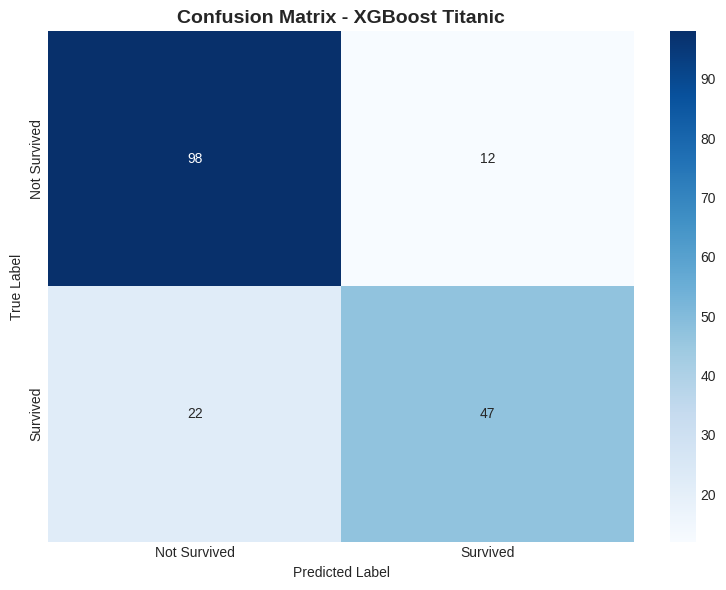

In [6]:
# ⚡ Train XGBoost on Titanic
print("\n" + "=" * 60)
print("🌲 TRAINING XGBOOST CLASSIFIER")
print("=" * 60)

# Initialize XGBoost with categorical support enabled
xgb_titanic = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    gamma=0.1,
    min_child_weight=3,
    random_state=42,
    eval_metric='logloss',
    # FIXES:
    enable_categorical=True,  # Allows pandas 'category' dtypes
    tree_method="hist"        # Required for native categorical support
)

# Train with evaluation set
eval_set = [(X_train_t, y_train_t), (X_test_t, y_test_t)]

xgb_titanic.fit(
    X_train_t, y_train_t,
    eval_set=eval_set,
    verbose=False
)

# Predictions
y_pred_t = xgb_titanic.predict(X_test_t)
y_pred_proba_t = xgb_titanic.predict_proba(X_test_t)[:, 1]

# Metrics
accuracy_t = accuracy_score(y_test_t, y_pred_t)
print(f"\n✅ Test Accuracy: {accuracy_t:.4f}")

print("\nClassification Report:")
print(classification_report(y_test_t, y_pred_t, target_names=['Not Survived', 'Survived']))

# Confusion Matrix Visual
cm = confusion_matrix(y_test_t, y_pred_t)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=['Not Survived', 'Survived'],
            yticklabels=['Not Survived', 'Survived'])
plt.title('Confusion Matrix - XGBoost Titanic', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

## 8. Feature Importance from XGBoost

XGBoost provides multiple ways to interpret feature importance:

1. **Weight** (default): Number of times a feature appears in trees
2. **Gain**: Average gain of splits using the feature
3. **Cover**: Average coverage of splits using the feature
4. **Total Gain**: Total gain across all splits
5. **Total Cover**: Total coverage across all splits

📊 FEATURE IMPORTANCE ANALYSIS


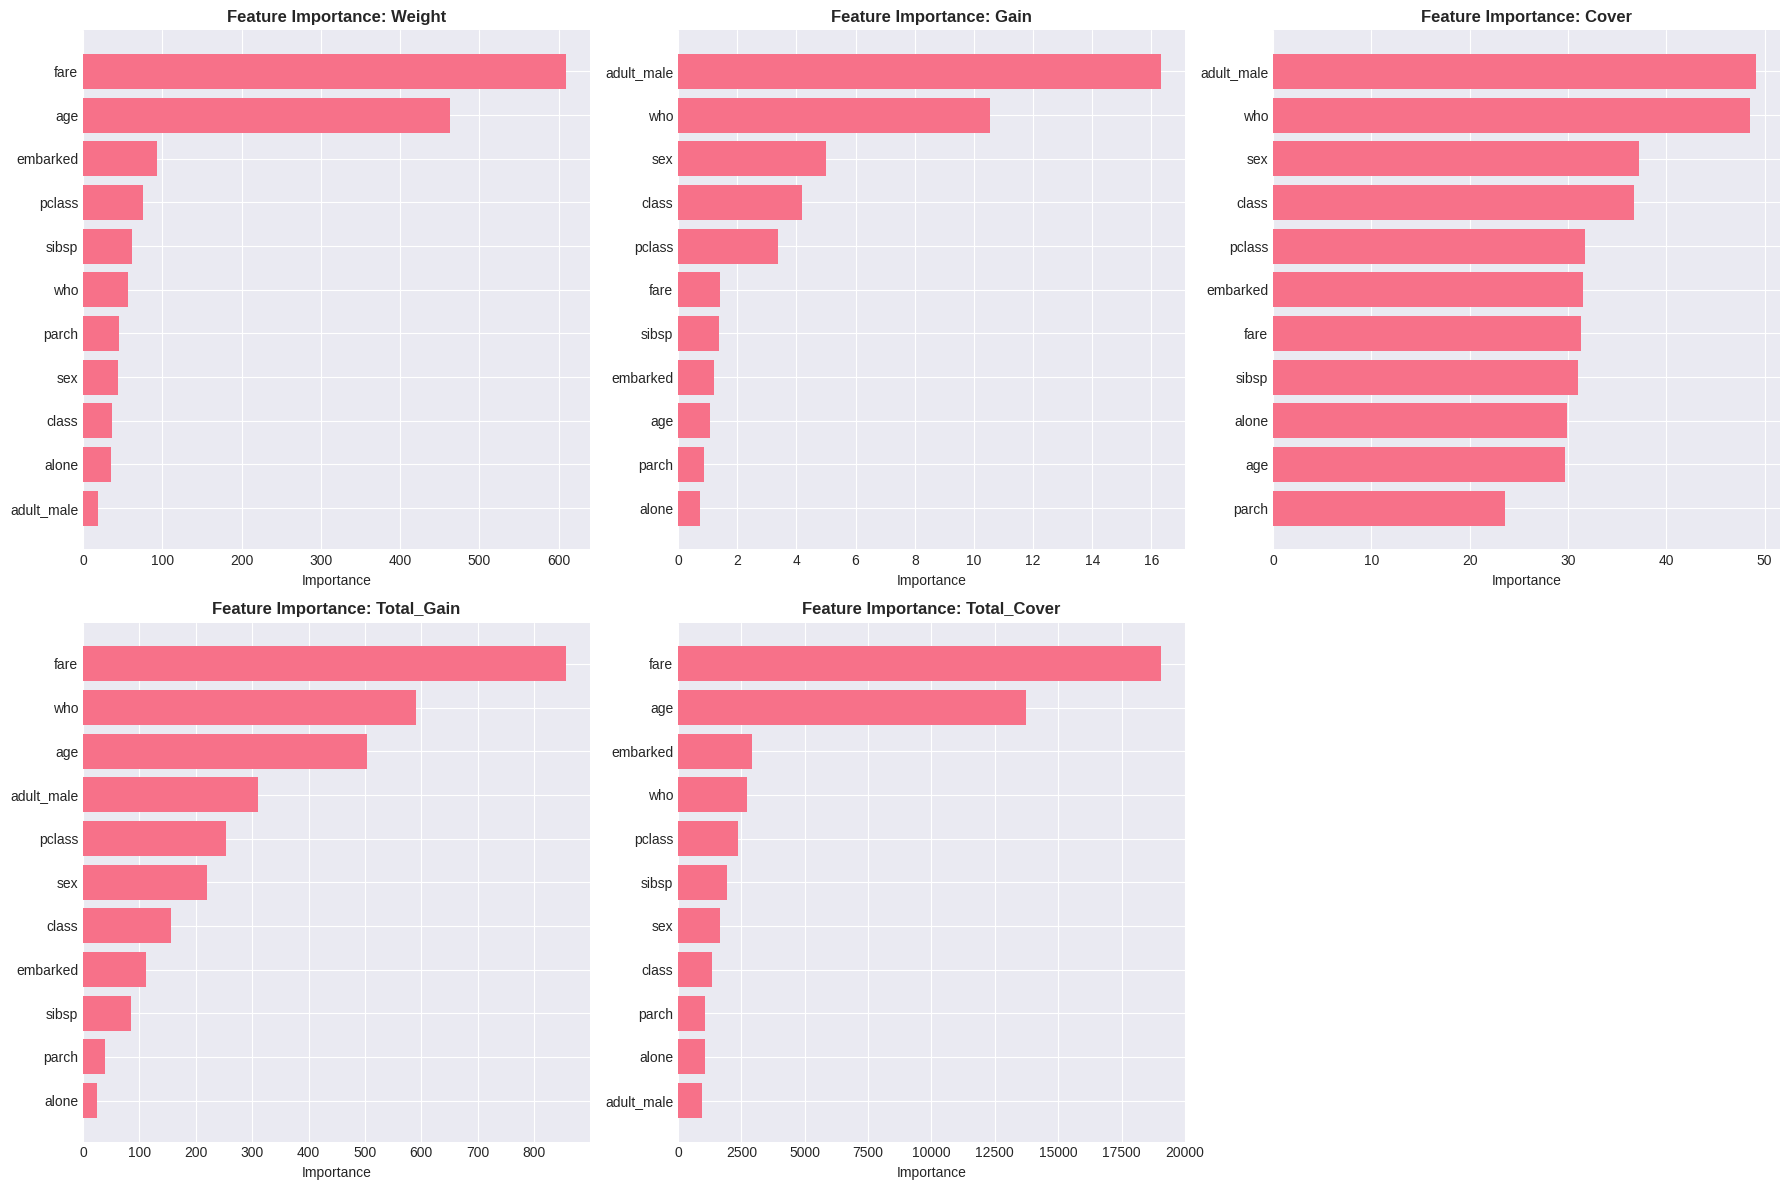

<Figure size 1000x800 with 0 Axes>

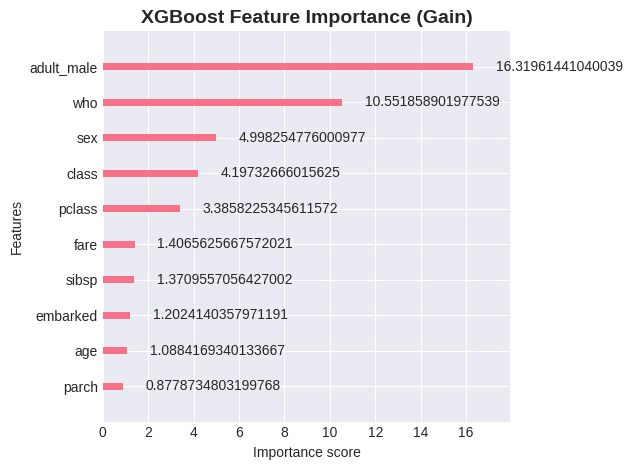


💡 Key Insights:
- 'Gain' shows which features contribute most to model accuracy
- 'Weight' shows which features are used most frequently
- High gain features are crucial for predictions


In [7]:
# ⚡ Feature Importance Analysis
print("=" * 60)
print("📊 FEATURE IMPORTANCE ANALYSIS")
print("=" * 60)

# Get feature importance
importance_types = ['weight', 'gain', 'cover', 'total_gain', 'total_cover']

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, imp_type in enumerate(importance_types):
    importance = xgb_titanic.get_booster().get_score(importance_type=imp_type)
    
    # Convert to DataFrame for plotting
    imp_df = pd.DataFrame({
        'feature': list(importance.keys()),
        'importance': list(importance.values())
    }).sort_values('importance', ascending=True)
    
    # Plot
    axes[idx].barh(imp_df['feature'], imp_df['importance'])
    axes[idx].set_title(f'Feature Importance: {imp_type.title()}', fontweight='bold')
    axes[idx].set_xlabel('Importance')

# Remove empty subplot
axes[5].remove()

plt.tight_layout()
plt.show()

# Built-in plot_importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(xgb_titanic, importance_type='gain', max_num_features=10)
plt.title('XGBoost Feature Importance (Gain)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n💡 Key Insights:")
print("- 'Gain' shows which features contribute most to model accuracy")
print("- 'Weight' shows which features are used most frequently")
print("- High gain features are crucial for predictions")

## 9. Early Stopping and Cross-Validation

Early stopping is a powerful technique to prevent overfitting and reduce training time. XGBoost monitors a validation metric and stops training when it stops improving.

⏹️ EARLY STOPPING DEMONSTRATION
[0]	validation_0-logloss:0.64260	validation_1-logloss:0.64595
[20]	validation_0-logloss:0.42465	validation_1-logloss:0.46925
[40]	validation_0-logloss:0.36021	validation_1-logloss:0.43999
[52]	validation_0-logloss:0.34323	validation_1-logloss:0.44085

✅ Best iteration: 37
✅ Ideal number of estimators: 38


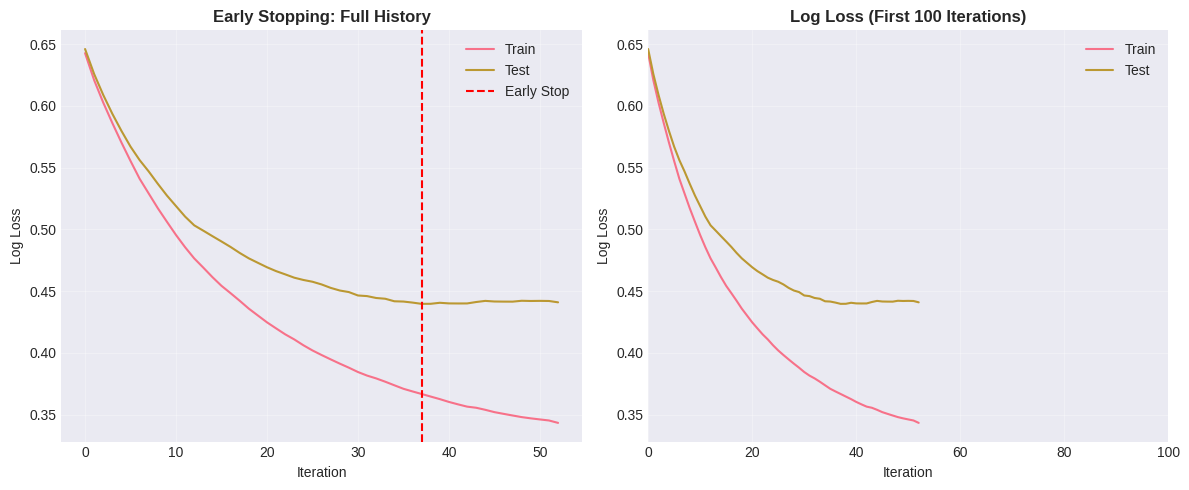

In [8]:
# ⚡ Early Stopping Demonstration
print("=" * 60)
print("⏹️ EARLY STOPPING DEMONSTRATION")
print("=" * 60)

# 1. Initialize with early_stopping_rounds
xgb_early = xgb.XGBClassifier(
    n_estimators=1000,         # Set high; early stopping will find the ideal cutoff
    max_depth=4,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    enable_categorical=True,    # Crucial for your 'category' dtypes
    tree_method="hist",         # Required for categorical support
    early_stopping_rounds=15    # Stops if test loss doesn't improve for 15 rounds
)

eval_set = [(X_train_t, y_train_t), (X_test_t, y_test_t)]

# 2. Fit the model
xgb_early.fit(
    X_train_t, y_train_t,
    eval_set=eval_set,
    verbose=20                 # Shows progress every 20 iterations
)

# 3. Use best_iteration instead of n_estimators
print(f"\n✅ Best iteration: {xgb_early.best_iteration}")
print(f"✅ Ideal number of estimators: {xgb_early.best_iteration + 1}")

# Get evaluation results
results = xgb_early.evals_result()

# Plot training progress
plt.figure(figsize=(12, 5))

# Plot 1: Full History
plt.subplot(1, 2, 1)
plt.plot(results['validation_0']['logloss'], label='Train')
plt.plot(results['validation_1']['logloss'], label='Test')
# Add a vertical line at the stopping point
plt.axvline(xgb_early.best_iteration, color='r', linestyle='--', label='Early Stop')
plt.xlabel('Iteration')
plt.ylabel('Log Loss')
plt.title('Early Stopping: Full History', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Plot 2: Zoomed View
plt.subplot(1, 2, 2)
plt.plot(results['validation_0']['logloss'], label='Train')
plt.plot(results['validation_1']['logloss'], label='Test')
plt.xlabel('Iteration')
plt.ylabel('Log Loss')
plt.title('Log Loss (First 100 Iterations)', fontweight='bold')
plt.xlim(0, 100)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


🔄 CROSS-VALIDATION WITH XGBOOST
CV Results shape: (62, 12)

Best iteration: 62
Best CV Error: 0.1639 (+/- 0.0023)
Best CV AUC: 0.8782


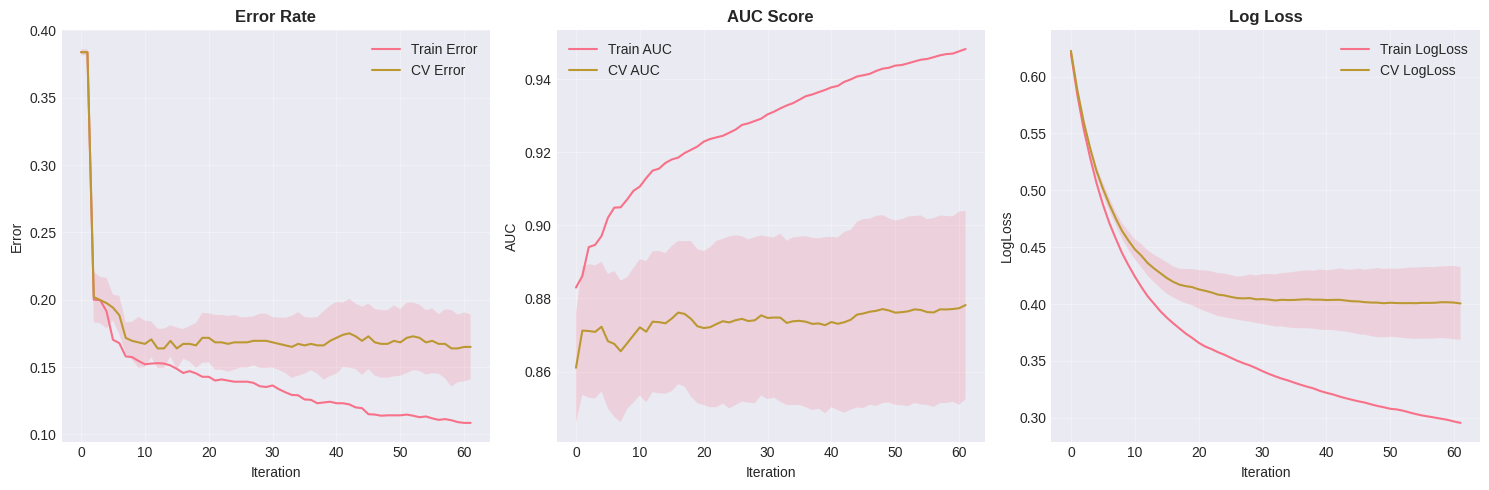

In [9]:
# ⚡ Cross-Validation with XGBoost
print("\n" + "=" * 60)
print("🔄 CROSS-VALIDATION WITH XGBOOST")
print("=" * 60)

import xgboost as xgb
import matplotlib.pyplot as plt

# 1. Create DMatrix with categorical support enabled
# Note: We pass enable_categorical=True here because X_titanic contains 'category' dtypes
dtrain = xgb.DMatrix(X_titanic, label=y_titanic, enable_categorical=True)

# 2. Parameters
params = {
    'max_depth': 4,
    'learning_rate': 0.1,
    'subsample': 0.8,
    'colsample_bytree': 0.8,
    'objective': 'binary:logistic',
    'tree_method': 'hist',     # Required for categorical support
    'seed': 42
}

# 3. Run cross-validation
# metrics are now passed directly here; 'eval_metric' in params is also an option
cv_results = xgb.cv(
    params=params,
    dtrain=dtrain,
    num_boost_round=200,
    nfold=5,
    early_stopping_rounds=20,
    metrics=['error', 'auc', 'logloss'],
    seed=42,
    stratified=True # Good practice for classification
)

print(f"CV Results shape: {cv_results.shape}")
print(f"\nBest iteration: {len(cv_results)}")
print(f"Best CV Error: {cv_results['test-error-mean'].min():.4f} (+/- {cv_results['test-error-std'].min():.4f})")
print(f"Best CV AUC: {cv_results['test-auc-mean'].max():.4f}")

# 4. Plot CV results
plt.figure(figsize=(15, 5))

# Subplot 1: Error Rate
plt.subplot(1, 3, 1)
plt.plot(cv_results['train-error-mean'], label='Train Error')
plt.plot(cv_results['test-error-mean'], label='CV Error')
plt.fill_between(range(len(cv_results)), 
                 cv_results['test-error-mean'] - cv_results['test-error-std'],
                 cv_results['test-error-mean'] + cv_results['test-error-std'],
                 alpha=0.2)
plt.xlabel('Iteration')
plt.ylabel('Error')
plt.title('Error Rate', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: AUC Score
plt.subplot(1, 3, 2)
plt.plot(cv_results['train-auc-mean'], label='Train AUC')
plt.plot(cv_results['test-auc-mean'], label='CV AUC')
plt.fill_between(range(len(cv_results)), 
                 cv_results['test-auc-mean'] - cv_results['test-auc-std'],
                 cv_results['test-auc-mean'] + cv_results['test-auc-std'],
                 alpha=0.2)
plt.xlabel('Iteration')
plt.ylabel('AUC')
plt.title('AUC Score', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 3: Log Loss
plt.subplot(1, 3, 3)
plt.plot(cv_results['train-logloss-mean'], label='Train LogLoss')
plt.plot(cv_results['test-logloss-mean'], label='CV LogLoss')
plt.fill_between(range(len(cv_results)), 
                 cv_results['test-logloss-mean'] - cv_results['test-logloss-std'],
                 cv_results['test-logloss-mean'] + cv_results['test-logloss-std'],
                 alpha=0.2)
plt.xlabel('Iteration')
plt.ylabel('LogLoss')
plt.title('Log Loss', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 10. Comparison: Random Forest vs XGBoost

Let's compare Random Forest and XGBoost on the same dataset to understand their differences.

In [10]:
# ⚡ Random Forest vs XGBoost Comparison
print("=" * 60)
print("⚔️ RANDOM FOREST vs XGBOOST COMPARISON")
print("=" * 60)

from sklearn.ensemble import RandomForestClassifier
from time import time
import pandas as pd

# --- PREPARE DATA FOR RANDOM FOREST ---
# RF doesn't support 'category' dtypes natively like XGBoost 2.0 does.
# We create a version of the data using .cat.codes for RF only.
X_train_rf = X_train_t.copy()
X_test_rf = X_test_t.copy()

for col in X_train_rf.select_dtypes(['category']).columns:
    X_train_rf[col] = X_train_rf[col].cat.codes
    X_test_rf[col] = X_test_rf[col].cat.codes

# --- RANDOM FOREST ---
print("\n🌲 Training Random Forest...")
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=5,
    random_state=42,
    n_jobs=-1
)

start_time = time()
rf.fit(X_train_rf, y_train_t)
rf_train_time = time() - start_time

rf_pred = rf.predict(X_test_rf)
rf_accuracy = accuracy_score(y_test_t, rf_pred)

print(f"✅ RF Training Time: {rf_train_time:.3f}s")
print(f"✅ RF Test Accuracy: {rf_accuracy:.4f}")

# --- XGBOOST ---
print("\n⚡ Training XGBoost...")
xgb_comp = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    eval_metric='logloss',
    # FIXES for categorical data:
    enable_categorical=True,
    tree_method='hist'
)

start_time = time()
xgb_comp.fit(X_train_t, y_train_t) # XGB uses the original categorical data
xgb_train_time = time() - start_time

xgb_pred = xgb_comp.predict(X_test_t)
xgb_accuracy = accuracy_score(y_test_t, xgb_pred)

print(f"✅ XGB Training Time: {xgb_train_time:.3f}s")
print(f"✅ XGB Test Accuracy: {xgb_accuracy:.4f}")

# --- COMPARISON SUMMARY ---
print("\n" + "=" * 60)
print("📊 COMPARISON SUMMARY")
print("=" * 60)

comparison_df = pd.DataFrame({
    'Metric': ['Training Time (s)', 'Test Accuracy', 'n_estimators', 'max_depth', 'Learning Rate'],
    'Random Forest': [f"{rf_train_time:.4f}", f"{rf_accuracy:.4f}", 200, 10, 'N/A'],
    'XGBoost': [f"{xgb_train_time:.4f}", f"{xgb_accuracy:.4f}", 200, 4, 0.1]
})
print(comparison_df.to_string(index=False))

print("\n💡 Key Differences:")
print("- Random Forest: Parallel tree building (Bagging). Each tree is independent.")
print("- XGBoost: Sequential tree building (Boosting). Each tree corrects the previous one.")
print("- Data Handling: XGBoost (v2.0+) handles 'category' dtypes natively; RF requires manual encoding.")
print("- Performance: XGBoost usually wins on accuracy, but RF is harder to 'break' with bad hyperparameters.")

⚔️ RANDOM FOREST vs XGBOOST COMPARISON

🌲 Training Random Forest...
✅ RF Training Time: 0.820s
✅ RF Test Accuracy: 0.8212

⚡ Training XGBoost...
✅ XGB Training Time: 0.099s
✅ XGB Test Accuracy: 0.8101

📊 COMPARISON SUMMARY
           Metric Random Forest XGBoost
Training Time (s)        0.8204  0.0991
    Test Accuracy        0.8212  0.8101
     n_estimators           200     200
        max_depth            10       4
    Learning Rate           N/A     0.1

💡 Key Differences:
- Random Forest: Parallel tree building (Bagging). Each tree is independent.
- XGBoost: Sequential tree building (Boosting). Each tree corrects the previous one.
- Data Handling: XGBoost (v2.0+) handles 'category' dtypes natively; RF requires manual encoding.
- Performance: XGBoost usually wins on accuracy, but RF is harder to 'break' with bad hyperparameters.


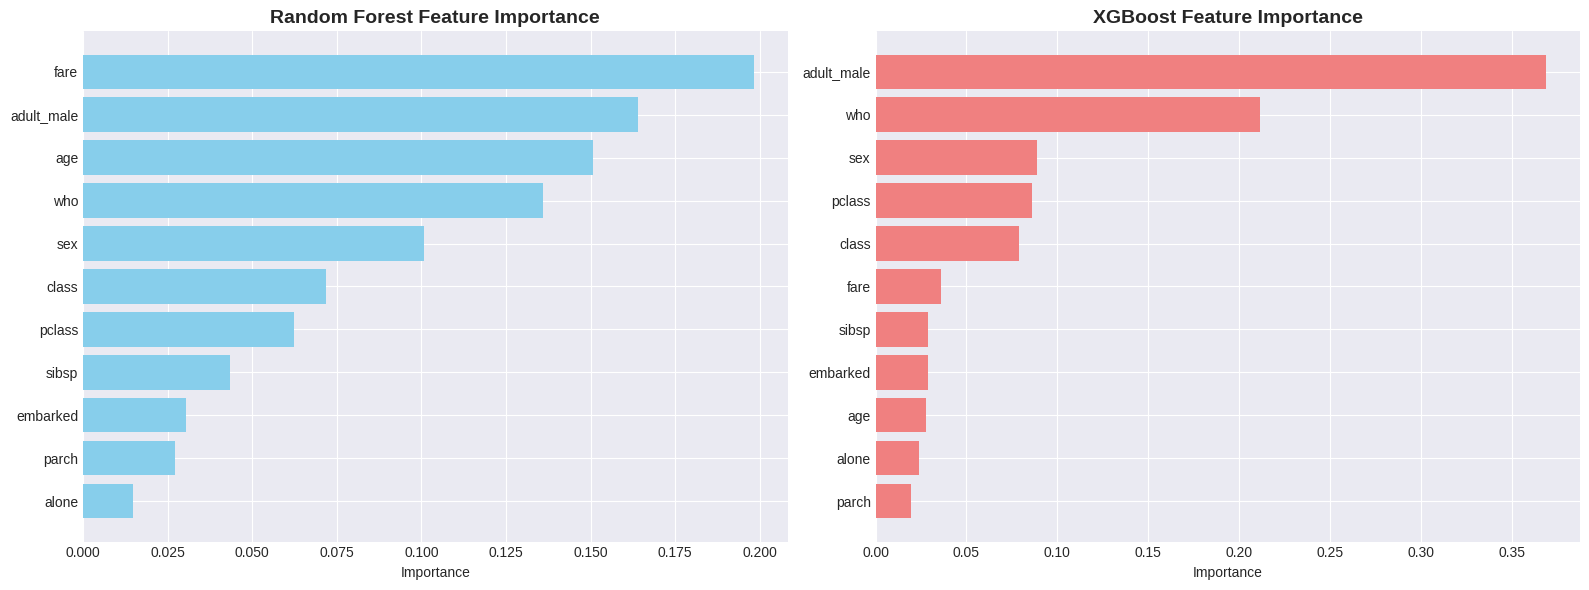

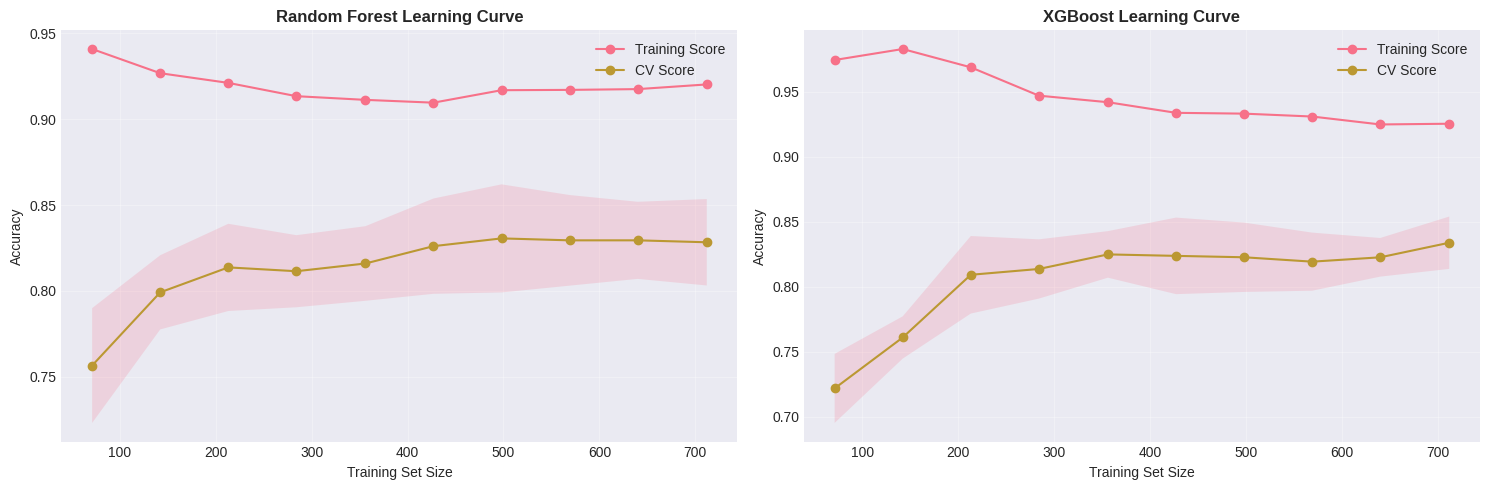

In [11]:
# ⚡ Visual Comparison of Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Random Forest Feature Importance
rf_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=True)

axes[0].barh(rf_importance['feature'], rf_importance['importance'], color='skyblue')
axes[0].set_title('Random Forest Feature Importance', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Importance')

# XGBoost Feature Importance
xgb_importance = pd.DataFrame({
    'feature': feature_names,
    'importance': xgb_comp.feature_importances_
}).sort_values('importance', ascending=True)

axes[1].barh(xgb_importance['feature'], xgb_importance['importance'], color='lightcoral')
axes[1].set_title('XGBoost Feature Importance', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Importance')

plt.tight_layout()
plt.show()

# Learning curves comparison
from sklearn.model_selection import learning_curve

train_sizes = np.linspace(0.1, 1.0, 10)

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Random Forest Learning Curve
train_sizes_rf, train_scores_rf, test_scores_rf = learning_curve(
    rf, X_titanic, y_titanic, cv=5, train_sizes=train_sizes, 
    scoring='accuracy', random_state=42, n_jobs=-1
)

axes[0].plot(train_sizes_rf, train_scores_rf.mean(axis=1), 'o-', label='Training Score')
axes[0].plot(train_sizes_rf, test_scores_rf.mean(axis=1), 'o-', label='CV Score')
axes[0].fill_between(train_sizes_rf, 
                     test_scores_rf.mean(axis=1) - test_scores_rf.std(axis=1),
                     test_scores_rf.mean(axis=1) + test_scores_rf.std(axis=1),
                     alpha=0.2)
axes[0].set_title('Random Forest Learning Curve', fontweight='bold')
axes[0].set_xlabel('Training Set Size')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# XGBoost Learning Curve
train_sizes_xgb, train_scores_xgb, test_scores_xgb = learning_curve(
    xgb_comp, X_titanic, y_titanic, cv=5, train_sizes=train_sizes,
    scoring='accuracy', random_state=42, n_jobs=-1
)

axes[1].plot(train_sizes_xgb, train_scores_xgb.mean(axis=1), 'o-', label='Training Score')
axes[1].plot(train_sizes_xgb, test_scores_xgb.mean(axis=1), 'o-', label='CV Score')
axes[1].fill_between(train_sizes_xgb,
                     test_scores_xgb.mean(axis=1) - test_scores_xgb.std(axis=1),
                     test_scores_xgb.mean(axis=1) + test_scores_xgb.std(axis=1),
                     alpha=0.2)
axes[1].set_title('XGBoost Learning Curve', fontweight='bold')
axes[1].set_xlabel('Training Set Size')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## 11. Practical Tips for Using XGBoost Effectively

### 🎯 General Guidelines:

**1. Handling Imbalanced Data:**
```python
scale_pos_weight = sum(negative_instances) / sum(positive_instances)
xgb.XGBClassifier(scale_pos_weight=scale_pos_weight)
```

**2. Dealing with Missing Values:**
- XGBoost handles missing values automatically
- Set `missing` parameter if using a specific value (e.g., -999)

**3. Categorical Features:**
- XGBoost doesn't handle categorical features natively
- Use one-hot encoding or target encoding

**4. Large Datasets:**
```python
# Use histogram-based algorithm
tree_method='hist'  # or 'gpu_hist' for GPU
```

### 🔧 Tuning Strategy:

**Step 1: Fix learning rate and tune n_estimators**
```python
learning_rate=0.1
n_estimators=100-1000 (use early stopping)
```

**Step 2: Tune tree-specific parameters**
```python
max_depth: 3-10 (start with 5-6)
min_child_weight: 1-6
gamma: 0-5
```

**Step 3: Tune regularization**
```python
subsample: 0.6-1.0
colsample_bytree: 0.6-1.0
reg_alpha: 0-1
reg_lambda: 1-10
```

**Step 4: Lower learning rate**
```python
learning_rate=0.01-0.05
n_estimators *= 2-3
```

### ⚡ Performance Optimization:

- Use `n_jobs=-1` for parallel processing
- Enable GPU with `tree_method='gpu_hist'`
- Use `predict()` with `ntree_limit` for faster prediction with fewer trees

## 🛠️ Hands-On Exercises

Now it's your turn! Complete these exercises to master XGBoost.

### Exercise 1: Basic XGBoost Training
Train an XGBoost classifier on the breast cancer dataset with default parameters and evaluate accuracy.

In [12]:
# Exercise 1: Your code here



### Exercise 2: Hyperparameter Tuning - Learning Rate
Experiment with different learning rates (0.01, 0.1, 0.3, 0.5) and plot how they affect training.

In [13]:
# Exercise 2: Your code here



### Exercise 3: Hyperparameter Tuning - Max Depth
Test max_depth values from 2 to 10 and observe the bias-variance tradeoff.

In [14]:
# Exercise 3: Your code here



### Exercise 4: Implement Early Stopping
Train XGBoost with early stopping on the Titanic dataset and find the optimal number of trees.

In [15]:
# Exercise 4: Your code here



### Exercise 5: Random Forest vs XGBoost Comparison
Compare Random Forest and XGBoost on the California housing dataset (regression).

In [16]:
# Exercise 5: Your code here



### Exercise 6: Feature Importance Analysis
Analyze and visualize feature importance using all three types (weight, gain, cover) on the breast cancer dataset.

In [17]:
# Exercise 6: Your code here



### Exercise 7: Cross-Validation with XGBoost
Perform 5-fold cross-validation on the Titanic dataset and report mean accuracy with standard deviation.

In [18]:
# Exercise 7: Your code here



### Exercise 8: Regularization Effects
Experiment with different values of reg_alpha (L1) and reg_lambda (L2) and observe their effect on model performance.

In [19]:
# Exercise 8: Your code here



### Exercise 9: Complete Pipeline with Preprocessing
Build a complete ML pipeline using sklearn's Pipeline that includes preprocessing (scaling, encoding) and XGBoost.

In [20]:
# Exercise 9: Your code here



### Exercise 10: Advanced - Custom Objective Function
Research and implement a custom evaluation metric for XGBoost (e.g., F1-score) using the callback API.

In [21]:
# Exercise 10: Your code here (Advanced)



## Solutions (Review After Attempting)

<details>
<summary>Exercise 1 Solution</summary>

```python
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import xgboost as xgb

# Load data
cancer = load_breast_cancer()
X, y = cancer.data, cancer.target

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train with defaults
model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

# Evaluate
y_pred = model.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
```
</details>

<details>
<summary>Exercise 2 Solution</summary>

```python
import matplotlib.pyplot as plt

learning_rates = [0.01, 0.1, 0.3, 0.5]
accuracies = []

for lr in learning_rates:
    model = xgb.XGBClassifier(learning_rate=lr, n_estimators=200, random_state=42, eval_metric='logloss')
    model.fit(X_train, y_train)
    acc = accuracy_score(y_test, model.predict(X_test))
    accuracies.append(acc)
    print(f"LR={lr}: Accuracy={acc:.4f}")

plt.plot(learning_rates, accuracies, 'o-')
plt.xlabel('Learning Rate')
plt.ylabel('Accuracy')
plt.title('Effect of Learning Rate')
plt.show()
```
</details>

<details>
<summary>Exercise 3 Solution</summary>

```python
max_depths = range(2, 11)
train_scores = []
test_scores = []

for depth in max_depths:
    model = xgb.XGBClassifier(max_depth=depth, random_state=42, eval_metric='logloss')
    model.fit(X_train, y_train)
    train_scores.append(accuracy_score(y_train, model.predict(X_train)))
    test_scores.append(accuracy_score(y_test, model.predict(X_test)))

plt.plot(max_depths, train_scores, label='Train')
plt.plot(max_depths, test_scores, label='Test')
plt.xlabel('Max Depth')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Max Depth vs Accuracy')
plt.show()
```
</details>

<details>
<summary>Exercise 4 Solution</summary>

```python
model = xgb.XGBClassifier(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    random_state=42,
    eval_metric='logloss'
)

model.fit(
    X_train_t, y_train_t,
    eval_set=[(X_test_t, y_test_t)],
    early_stopping_rounds=50,
    verbose=False
)

print(f"Best iteration: {model.best_iteration}")
print(f"Best score: {model.best_score:.4f}")
```
</details>

<details>
<summary>Exercise 5 Solution</summary>

```python
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing()
X, y = housing.data, housing.target
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf.predict(X_test)))

# XGBoost
xgb_reg = xgb.XGBRegressor(n_estimators=100, random_state=42)
xgb_reg.fit(X_train, y_train)
xgb_rmse = np.sqrt(mean_squared_error(y_test, xgb_reg.predict(X_test)))

print(f"RF RMSE: {rf_rmse:.4f}")
print(f"XGB RMSE: {xgb_rmse:.4f}")
```
</details>

<details>
<summary>Exercise 6 Solution</summary>

```python
import pandas as pd

model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

for idx, imp_type in enumerate(['weight', 'gain', 'cover']):
    importance = model.get_booster().get_score(importance_type=imp_type)
    imp_df = pd.DataFrame({
        'feature': list(importance.keys()),
        'importance': list(importance.values())
    }).sort_values('importance', ascending=True)
    
    axes[idx].barh(imp_df['feature'], imp_df['importance'])
    axes[idx].set_title(f'Importance: {imp_type}')

plt.tight_layout()
plt.show()
```
</details>

<details>
<summary>Exercise 7 Solution</summary>

```python
from sklearn.model_selection import cross_val_score

model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
scores = cross_val_score(model, X_titanic, y_titanic, cv=5, scoring='accuracy')

print(f"CV Scores: {scores}")
print(f"Mean: {scores.mean():.4f} (+/- {scores.std():.4f})")
```
</details>

<details>
<summary>Exercise 8 Solution</summary>

```python
alphas = [0, 0.1, 0.5, 1, 2]
lambdas = [0.1, 1, 5, 10]

results = []
for alpha in alphas:
    for lam in lambdas:
        model = xgb.XGBClassifier(reg_alpha=alpha, reg_lambda=lam, random_state=42, eval_metric='logloss')
        model.fit(X_train, y_train)
        acc = accuracy_score(y_test, model.predict(X_test))
        results.append({'alpha': alpha, 'lambda': lam, 'accuracy': acc})

results_df = pd.DataFrame(results)
pivot = results_df.pivot(index='alpha', columns='lambda', values='accuracy')
sns.heatmap(pivot, annot=True, fmt='.4f')
plt.title('Regularization Effects')
plt.show()
```
</details>

<details>
<summary>Exercise 9 Solution</summary>

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Define preprocessing
numeric_features = ['age', 'fare', 'sibsp', 'parch']
categorical_features = ['pclass', 'sex', 'embarked']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(), categorical_features)
    ])

# Create pipeline
pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', xgb.XGBClassifier(random_state=42, eval_metric='logloss'))
])

# Fit and evaluate
pipeline.fit(X_train_t, y_train_t)
print(f"Pipeline Accuracy: {pipeline.score(X_test_t, y_test_t):.4f}")
```
</details>

<details>
<summary>Exercise 10 Solution</summary>

```python
from sklearn.metrics import f1_score

# Custom callback for F1 score
class F1ScoreCallback(xgb.callback.TrainingCallback):
    def __init__(self, test_data):
        self.test_data = test_data
        self.f1_scores = []
    
    def after_iteration(self, model, epoch, evals_log):
        X_test, y_test = self.test_data
        y_pred = model.predict(xgb.DMatrix(X_test))
        y_pred_binary = (y_pred > 0.5).astype(int)
        f1 = f1_score(y_test, y_pred_binary)
        self.f1_scores.append(f1)
        return False  # Don't stop early

callback = F1ScoreCallback((X_test, y_test))
model = xgb.XGBClassifier(random_state=42, eval_metric='logloss')
model.fit(X_train, y_train, callbacks=[callback])

plt.plot(callback.f1_scores)
plt.xlabel('Iteration')
plt.ylabel('F1 Score')
plt.title('F1 Score During Training')
plt.show()
```
</details>